# **EfficientNet-V2B3 (Configuration 4)** 

This final configuration completely shifts the objective to **Ordinal Regression**, utilizing custom thresholding, soft enhancement, and full backbone unfreezing to respect the ordered nature of KOA severity grades.

**1. Model Architecture & Output**
*   **Classifier Head**: The custom network is adjusted for regression: `GAP -> Batch Normalization -> Dense(256) -> Dropout(0.6) -> Dense(1)`. 
    *   *Dropout* is increased to *0.6* for maximum regularization.
    *   *L2 Regularization (2e-4)* is doubled compared to C3.
*   **Output Formulation & Thresholding**: The output is changed to **Linear (ordinal regression)**. Instead of probabilities, it outputs a single continuous value. Custom threshold optimization maps this continuous output back to the ordered KL grades (0-4).

**2. Data Pipeline**
*   **Preprocessing & Augmentation**: Images are resized, and a **Soft CLAHE (clipLimit=1.5)** is applied alongside **Letterbox padding** to preserve the original aspect ratio of the joint without distortion.
*   **Class Weights**: Changed to **Square-root smoothed**, providing a more tempered approach to class balancing than the standard sklearn method, ideal for regression tasks.

**3. Two-Phase Training Strategy**
The loss function is changed to **Mean Absolute Error (MAE)**, trained in two phases, keeping Backbone Batch Normalization layers **Frozen**:
*   **Phase 1 (Warm-up)**: Base layers frozen. The head is trained using the **Adam optimizer** at a learning rate of **1e-3 (0.001)**. (Early Stopping Patience = 5).
*   **Phase 2 (Fine-tuning)**: **All layers** of the backbone are unfrozen. The learning rate drops to **1e-5 (0.00001)** using **AdamW** (with a stronger Weight Decay of 2e-4) for full-network adaptation. (Early Stopping Patience = 7).

### **Model Configuration**

| Parameter | Configuration 4 |
| :--- | :--- |
| **Output Formulation** | Linear (ordinal regression) |
| **Loss Function** | Mean Absolute Error (MAE) |
| **Preprocessing** | Soft CLAHE (clip=1.5) + Letterbox padding |
| **Phase 1 Optimizer** | Adam (LR=1e-3) |
| **Phase 2 Optimizer** | AdamW (LR=1e-5, WD=2e-4) |
| **Unfrozen Layers (P2)** | All (BN Frozen) |
| **Class Weights** | Square-root smoothed |
| **Classifier Head** | GAP → BN → Dense(256) → DO(0.6) → Dense(1) |
| **L2 Regularization** | 2e-4 |
| **Early Stopping** | P1: Patience=5, P2: Patience=7 |





## **1.0 Environment Setup**

First, let's import all the necessary libraries for data handling, visualization, and deep learning model building.

In [ ]:
import json
import os
import timeit
from pathlib import Path

import cv2
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from PIL import Image
from scipy.optimize import minimize
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    cohen_kappa_score, confusion_matrix, mean_absolute_error,
    precision_recall_fscore_support, roc_auc_score, roc_curve, auc,
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import Sequence


SEED = 12049
tf.keras.utils.set_random_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as exc:
            print(f'Could not enable memory growth for {gpu}: {exc}')

print('TF version:', tf.__version__)
print('GPUs:', gpus)




I0000 00:00:1780826595.919428   20758 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
MODEL_NAME: EfficientNetV2B3_C4


W0000 00:00:1780826599.188898   20758 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


### **Helper Functions**
These utility functions will be used throughout the notebook for:
- Loading and analyzing dataset statistics
- Visualizing sample images from each class
- Computing metrics and training curves

In [ ]:
def pad_to_square(image):
    img = np.asarray(image)
    old_size = img.shape[:2]  # (height, width)
    ratio = float(224) / max(old_size)
    new_size = tuple([int(x * ratio) for x in old_size])  # (new_h, new_w)
    # cv2.resize expects (width, height), so pass new_size[1] first.
    img = cv2.resize(img, (new_size[1], new_size[0]))  
    delta_w = 224 - new_size[1]
    delta_h = 224 - new_size[0]
    top, bottom = delta_h // 2, delta_h - (delta_h // 2)
    left, right = delta_w // 2, delta_w - (delta_w // 2)
    color = [0, 0, 0]
    padded = cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)
    # Guarantee exactly 224×224 regardless of rounding in new_size.
    return cv2.resize(padded, (224, 224))


def apply_soft_clahe(image):
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    if len(image.shape) == 3:
        # Apply CLAHE to each channel independently to preserve colour information.
        # Converting to greyscale first would make all three channels identical.
        r, g, b = cv2.split(image)
        r_enhanced = clahe.apply(r)
        g_enhanced = clahe.apply(g)
        b_enhanced = clahe.apply(b)
        return cv2.merge([r_enhanced, g_enhanced, b_enhanced])
    return clahe.apply(image)


def preprocess_for_efficientnet_c3(image):
    img_array = np.array(image, dtype=np.uint8)
    if img_array.ndim == 2:
        img_array = cv2.cvtColor(img_array, cv2.COLOR_GRAY2RGB)
    elif img_array.shape[-1] == 4:
        img_array = cv2.cvtColor(img_array, cv2.COLOR_RGBA2RGB)
    img_padded = pad_to_square(img_array)
    img_clahe = apply_soft_clahe(img_padded)
    return np.array(img_clahe, dtype=np.float32)


def prepare_display_image(image):
    img_array = np.array(image, dtype=np.uint8)
    if img_array.ndim == 2:
        img_array = cv2.cvtColor(img_array, cv2.COLOR_GRAY2RGB)
    elif img_array.shape[-1] == 4:
        img_array = cv2.cvtColor(img_array, cv2.COLOR_RGBA2RGB)
    return apply_soft_clahe(pad_to_square(img_array))


def collect_split_samples(split_path):
    samples = []
    for class_index in range(NUM_CLASSES):
        class_dir = Path(split_path) / str(class_index)
        if not class_dir.exists():
            continue
        for image_path in sorted(class_dir.iterdir()):
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
                samples.append((str(image_path), class_index))
    return samples


def get_classes(data_path, classes, data_name):
    print(f'---- {data_name} ----')
    knee_severity = {}
    total_count = 0
    for index in range(len(classes)):
        class_dir = os.path.join(data_path, str(index))
        image_names = []
        if os.path.exists(class_dir):
            image_names = sorted([name for name in os.listdir(class_dir) if Path(name).suffix.lower() in IMAGE_EXTENSIONS])
        knee_severity[index] = image_names
        total_count += len(image_names)
    for index, image_names in knee_severity.items():
        percentage = round((len(image_names) * 100) / total_count, 2) if total_count else 0
        print(f'Grade {index} - {classes[index]}: {len(image_names)} images, {percentage}%')
    return knee_severity


def threshold_predictions(predictions, thresholds):
    thresholds = np.sort(np.asarray(thresholds, dtype=np.float32))
    pred_values = np.asarray(predictions).reshape(-1)
    pred_labels = np.digitize(pred_values, thresholds, right=False).astype(int)
    pred_labels = np.clip(pred_labels, 0, NUM_CLASSES - 1)
    return pred_values, pred_labels


def plot_confusion_matrix(y_true, y_pred, class_names, title, normalize=False):
    matrix = confusion_matrix(y_true=y_true, y_pred=y_pred)
    if normalize:
        matrix = matrix.astype(float) / np.maximum(matrix.sum(axis=1, keepdims=True), 1)
    plt.figure(figsize=(7, 6))
    sns.heatmap(matrix, annot=True, fmt='.2f' if normalize else 'd', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()


def plot_training_history(history_dict, title):
    plt.figure(figsize=(10, 8))
    plt.subplot(2, 1, 1)
    plt.plot(history_dict.get('loss', []), label='train')
    plt.plot(history_dict.get('val_loss', []), label='valid')
    plt.title(f'{title} - Loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(loc='upper right')

    plt.subplot(2, 1, 2)
    plt.plot(history_dict.get('mae', []), label='train')
    plt.plot(history_dict.get('val_mae', []), label='valid')
    plt.title(f'{title} - MAE')
    plt.ylabel('mae')
    plt.xlabel('epoch')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


def merge_histories(*histories):
    combined = {}
    for history_obj in histories:
        for key, values in history_obj.history.items():
            combined.setdefault(key, []).extend(values)
    return combined


def get_last_conv_layer_name(backbone):
    for layer in reversed(backbone.layers):
        if isinstance(layer, layers.Conv2D):
            return layer.name
    raise ValueError('Could not find a suitable convolutional layer for Grad-CAM')


def make_gradcam_heatmap(feature_model, head_model, img_array):
    with tf.GradientTape() as tape:
        last_conv_layer_output = feature_model(img_array)
        tape.watch(last_conv_layer_output)
        preds = head_model(last_conv_layer_output)
        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output * pooled_grads
    heatmap = tf.reduce_sum(heatmap, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())
    return heatmap.numpy()


def overlay_heatmap(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap('jet')
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = (jet_heatmap * 255).astype(np.uint8)
    jet_heatmap = cv2.resize(jet_heatmap, (img.shape[1], img.shape[0]))
    superimposed_img = np.clip(jet_heatmap * alpha + img, 0, 255).astype(np.uint8)
    return superimposed_img


# ─────────────────────────────────────────────────────────────────────────────
# COMPREHENSIVE EVALUATION METRICS MATRIX
# Reports 6 metrics on any split: Accuracy, Balanced Accuracy, MAE (discrete),
# Macro ROC AUC (ordinal score matrix), Weighted ROC AUC, QWK.
#
# NOTE FOR ORDINAL REGRESSION:
# The model outputs a single continuous score, not per-class probabilities.
# For ROC AUC we construct proxy softmax-like probabilities using a Gaussian
# kernel centred on the continuous prediction so that the ordinal score matrix
# and OvR AUC remain well-defined and comparable to classification notebooks.
# ─────────────────────────────────────────────────────────────────────────────

def _ordinal_score_matrix(y_true_bin, y_pred_probs, n_classes):
    """
    Macro ROC-AUC via OvR (One-vs-Rest), averaged across classes.
    Uses the Gaussian proxy probabilities from continuous_to_probs.
    Replaces the broken ordinal score matrix that always collapsed to 0.5.
    """
    try:
        return float(roc_auc_score(
            y_true_bin, y_pred_probs,
            multi_class='ovr', average='macro'
        ))
    except Exception:
        return float('nan')


def continuous_to_probs(continuous_preds, n_classes=NUM_CLASSES, sigma=0.6):
    """
    Convert continuous ordinal regression scores to proxy class probabilities
    using a Gaussian kernel centred on each prediction.

    Each class k gets weight proportional to exp(-0.5 * ((pred - k) / sigma)^2).
    The result is L1-normalised so probabilities sum to 1.

    sigma=0.6 approximates the natural uncertainty around a grade boundary
    (one class ≈ 1 unit apart) while keeping adjacent-class probabilities
    large enough for meaningful AUC computation.
    """
    class_centres = np.arange(n_classes, dtype=np.float32)           # [0,1,2,3,4]
    preds = np.asarray(continuous_preds, dtype=np.float32).reshape(-1, 1)  # (N,1)
    weights = np.exp(-0.5 * ((preds - class_centres) / sigma) ** 2)  # (N, C)
    probs = weights / weights.sum(axis=1, keepdims=True)              # L1 normalise
    return probs                                                       # (N, C)


def comprehensive_evaluation_metrics_matrix(
    y_true, continuous_preds, pred_labels, split_name, class_names, model_name
):
    """
    Compute and display the full Comprehensive Evaluation Metrics Matrix.

    Parameters
    ----------
    y_true           : array-like of int, true class labels (0-4)
    continuous_preds : array of shape (N,), raw regression outputs
    pred_labels      : array of shape (N,), thresholded discrete predictions (0-4)
    split_name       : str, e.g. 'Validation' or 'Test'
    class_names      : list of str
    model_name       : str

    Returns
    -------
    dict of metric_name -> float
    """
    y_true        = np.asarray(y_true)
    pred_labels   = np.asarray(pred_labels)
    n_classes     = len(class_names)
    y_true_bin    = label_binarize(y_true, classes=range(n_classes))  # (N, C)
    y_pred_probs  = continuous_to_probs(continuous_preds, n_classes)  # (N, C)

    # ── 1. Overall Accuracy ───────────────────────────────────────────────
    accuracy     = accuracy_score(y_true, pred_labels)

    # ── 2. Balanced Accuracy ─────────────────────────────────────────────
    bal_accuracy = balanced_accuracy_score(y_true, pred_labels)

    # ── 3. MAE on discrete labels (grade-level error) ─────────────────────
    # Reporting MAE on continuous values gives a smaller, misleading number.
    mae          = mean_absolute_error(y_true, pred_labels)

    # ── 4. Macro ROC AUC — ordinal score matrix ───────────────────────────
    macro_auc_ordinal = _ordinal_score_matrix(y_true_bin, y_pred_probs, n_classes)

    # ── 5. Weighted ROC AUC — standard OvR ───────────────────────────────
    try:
        weighted_auc = roc_auc_score(
            y_true_bin, y_pred_probs,
            multi_class='ovr', average='weighted',
        )
    except Exception:
        weighted_auc = float('nan')

    # ── 6. Quadratic Weighted Kappa ───────────────────────────────────────
    qwk = cohen_kappa_score(y_true, pred_labels, weights='quadratic')

    # ── Display ───────────────────────────────────────────────────────────
    sep  = '=' * 72
    sep2 = '-' * 72
    print(f'\n{sep}')
    print(f'  COMPREHENSIVE EVALUATION METRICS MATRIX')
    print(f'  Model : {model_name}')
    print(f'  Split : {split_name}')
    print(f'{sep}')
    print(f'  {"Metric":<40} {"Value":>10}')
    print(f'  {sep2}')
    print(f'  {"Overall Accuracy":<40} {accuracy:>10.4f}')
    print(f'  {"Balanced Accuracy":<40} {bal_accuracy:>10.4f}')
    print(f'  {"Mean Absolute Error (MAE)":<40} {mae:>10.4f}')
    print(f'  {"Macro ROC AUC (ordinal matrix)":<40} {macro_auc_ordinal:>10.4f}')
    print(f'  {"Weighted ROC AUC":<40} {weighted_auc:>10.4f}')
    print(f'  {"Quadratic Weighted Kappa (QWK)":<40} {qwk:>10.4f}')
    print(f'{sep}')

    # ── Per-class breakdown ───────────────────────────────────────────────
    print(f'\n  PER-CLASS BREAKDOWN')
    print(f'  {sep2}')
    print(f'  {"Class":<14} {"Precision":>10} {"Recall":>10} {"F1":>10} {"Support":>10}')
    print(f'  {sep2}')
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, pred_labels, labels=range(n_classes), zero_division=0
    )
    for i, cname in enumerate(class_names):
        print(f'  {cname:<14} {prec[i]:>10.4f} {rec[i]:>10.4f} {f1[i]:>10.4f} {int(sup[i]):>10}')
    print(f'  {sep2}')

    # ── Save CSV ──────────────────────────────────────────────────────────
    metrics_dict = {
        'Split':                    split_name,
        'Overall Accuracy':         round(accuracy,          4),
        'Balanced Accuracy':        round(bal_accuracy,      4),
        'MAE':                      round(mae,               4),
        'Macro ROC AUC (ordinal)':  round(macro_auc_ordinal, 4),
        'Weighted ROC AUC':         round(weighted_auc,      4),
        'Quadratic Weighted Kappa': round(qwk,               4),
    }
    csv_path = f'metrics_{split_name.lower().replace(" ", "_")}.csv'
    pd.DataFrame([metrics_dict]).to_csv(csv_path, index=False)
    print(f'\n  Saved metrics to: {csv_path}')
    print(f'{sep}\n')
    return metrics_dict


def plot_roc_curves(y_true, y_pred_probs, class_names, model_name):
    """Per-class OvR ROC curves."""
    n_classes  = len(class_names)
    y_true_bin = label_binarize(np.asarray(y_true), classes=range(n_classes))
    plt.figure(figsize=(12, 8))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], np.asarray(y_pred_probs)[:, i])
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {auc(fpr, tpr):.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate',  fontsize=12)
    plt.title(f'ROC Curves (OvR) — {model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


def plot_f1_per_class(y_true, y_pred_labels, class_names, model_name):
    """Bar chart of per-class F1 scores."""
    from sklearn.metrics import f1_score as _f1
    scores = _f1(np.asarray(y_true), np.asarray(y_pred_labels),
                 labels=range(len(class_names)), average=None, zero_division=0)
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(class_names)))
    plt.figure(figsize=(10, 6))
    bars = plt.bar(class_names, scores, color=colors, edgecolor='black', linewidth=1.2)
    for bar, s in zip(bars, scores):
        plt.text(bar.get_x() + bar.get_width() / 2, s + 0.01,
                 f'{s:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    plt.ylabel('F1 Score', fontsize=12, fontweight='bold')
    plt.xlabel('KL Grade', fontsize=12, fontweight='bold')
    plt.title(f'Per-Class F1 Score — {model_name}', fontsize=14, fontweight='bold')
    plt.ylim([0, 1.1]); plt.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

## **2.0 Dataset Configuration**

### Class Definitions
The model classifies knee osteoarthritis into five severity grades based on radiographic evidence.

In [ ]:
def find_dataset_dir() -> Path:
    search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    candidate_suffixes = [
        ('data', 'knee_osteoarthritis'),
        ('ml_workflow', 'data', 'knee_osteoarthritis'),
        ('Final_year_project', 'ml_workflow', 'data', 'knee_osteoarthritis'),
    ]
    for root in search_roots:
        for suffix in candidate_suffixes:
            candidate = root.joinpath(*suffix)
            if candidate.exists():
                return candidate.resolve()
    raise FileNotFoundError('Dataset directory not found')


BASE_DIR = find_dataset_dir()
TRAIN_PATH = BASE_DIR / 'train_balanced'
VALID_PATH = BASE_DIR / 'val'
TEST_PATH = BASE_DIR / 'test'

print('BASE_DIR:', BASE_DIR)
print('TRAIN_PATH:', TRAIN_PATH)
print('VALID_PATH:', VALID_PATH)
print('TEST_PATH:', TEST_PATH)
print('CLASS_NAMES:', CLASS_NAMES)

print('Comprehensive Evaluation Metrics Matrix helpers defined.')


BASE_DIR: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis
TRAIN_PATH: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis/train_balanced
VALID_PATH: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis/val
TEST_PATH: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis/test
CLASS_NAMES: ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']
Comprehensive Evaluation Metrics Matrix helpers defined.


### Data Paths
The balanced dataset is split into three subsets: training (balanced), validation, and test. The balanced training set ensures equal representation across all severity classes.

In [3]:
class KOASequence(Sequence):
    def __init__(self, samples, batch_size, shuffle=False, augment=False, seed=SEED):
        self.samples = list(samples)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.rng = np.random.default_rng(seed)
        self.indices = np.arange(len(self.samples))
        self.classes = np.asarray([label for _, label in self.samples], dtype=np.int32)
        self.datagen = ImageDataGenerator(
            preprocessing_function=preprocess_for_efficientnet_c3,
            rotation_range=5,
            width_shift_range=0.05,
            height_shift_range=0.05,
            zoom_range=0.1,
            horizontal_flip=True,
            fill_mode='nearest',
        )
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.samples) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_images = []
        batch_labels = []
        for sample_index in batch_indices:
            image_path, label = self.samples[sample_index]
            image = Image.open(image_path).convert('RGB')
            processed = self.datagen.preprocessing_function(image)
            if self.augment:
                transform = self.datagen.get_random_transform(
                    processed.shape,
                    seed=int(self.rng.integers(0, 1_000_000_000)),
                )
                processed = self.datagen.apply_transform(processed, transform)
                processed = np.clip(processed, 0.0, 255.0)
            batch_images.append(processed)
            batch_labels.append(label)
        return np.asarray(batch_images, dtype=np.float32), np.asarray(batch_labels, dtype=np.int32)

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.indices)

    def reset(self):
        self.indices = np.arange(len(self.samples))
        if self.shuffle:
            self.rng.shuffle(self.indices)


def get_split_data(split_path, split_name):
    print(f'---- {split_name} ----')
    split_data = get_classes(str(split_path), CLASS_NAMES, split_name)
    split_samples = collect_split_samples(split_path)
    print(f'{split_name} samples: {len(split_samples)}')
    return split_data, split_samples


train_data, train_samples = get_split_data(TRAIN_PATH, 'train_balanced')
valid_data, valid_samples = get_split_data(VALID_PATH, 'val')
test_data, test_samples = get_split_data(TEST_PATH, 'test')

train_sequence = KOASequence(train_samples, batch_size=BATCH_SIZE, shuffle=True, augment=True, seed=SEED)
valid_sequence = KOASequence(valid_samples, batch_size=BATCH_SIZE, shuffle=False, augment=False, seed=SEED)
test_sequence = KOASequence(test_samples, batch_size=BATCH_SIZE, shuffle=False, augment=False, seed=SEED)

train_classes = train_sequence.classes
raw_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes),
    y=train_classes,
)
smoothed_class_weights = {
    int(cls): float(np.sqrt(weight))
    for cls, weight in zip(np.unique(train_classes), raw_class_weights)
}

print('Raw Class Weights:', dict(zip(np.unique(train_classes), raw_class_weights)))
print('Smoothed Class Weights:', smoothed_class_weights)
print('Train batches:', len(train_sequence))
print('Validation batches:', len(valid_sequence))
print('Test batches:', len(test_sequence))

---- train_balanced ----
---- train_balanced ----
Grade 0 - Healthy: 2246 images, 20.01%
Grade 1 - Doubtful: 2245 images, 20.0%
Grade 2 - Minimal: 2245 images, 20.0%
Grade 3 - Moderate: 2245 images, 20.0%
Grade 4 - Severe: 2245 images, 20.0%
train_balanced samples: 11226
---- val ----
---- val ----
Grade 0 - Healthy: 328 images, 39.71%
Grade 1 - Doubtful: 153 images, 18.52%
Grade 2 - Minimal: 212 images, 25.67%
Grade 3 - Moderate: 106 images, 12.83%
Grade 4 - Severe: 27 images, 3.27%
val samples: 826
---- test ----
---- test ----
Grade 0 - Healthy: 639 images, 38.59%
Grade 1 - Doubtful: 296 images, 17.87%
Grade 2 - Minimal: 447 images, 26.99%
Grade 3 - Moderate: 223 images, 13.47%
Grade 4 - Severe: 51 images, 3.08%
test samples: 1656
Raw Class Weights: {0: 0.9996438112199466, 1: 1.0000890868596881, 2: 1.0000890868596881, 3: 1.0000890868596881, 4: 1.0000890868596881}
Smoothed Class Weights: {0: 0.9998218897483424, 1: 1.0000445424378297, 2: 1.0000445424378297, 3: 1.0000445424378297, 4: 1

## **4.0 Model Configuration**

### Training Parameters
Define all hyperparameters and paths for the EfficientNet-V2B2 model. These settings have been optimized for balanced accuracy across all osteoarthritis severity grades.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — EfficientNet-V2B3 C4
# ══════════════════════════════════════════════════════════════════════════════

MODEL_NAME = 'EfficientNetV2B3_C4'
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = 5
CLASS_NAMES = ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']

# Training phases
PHASE1_MAX_EPOCHS = 15   # Head warm-up (backbone frozen)
PHASE2_MAX_EPOCHS = 35   # Full fine-tune
PHASE1_LR = 1e-3
PHASE2_LR = 1e-5
WEIGHT_DECAY = 2e-4

# Architecture
HEAD_DENSE_UNITS = 256
DROPOUT_RATE = 0.6
L2_REG = 2e-4

# Loss & formulation
LOSS = 'mae'              # Ordinal regression
OUTPUT_UNITS = 1          # Single linear output (not 5-class softmax)

# ══════════════════════════════════════════════════════════════════════════════
# DATA PIPELINE — KOASequence with soft CLAHE + runtime augmentation
# ══════════════════════════════════════════════════════════════════════════════
BASE_DIR = find_dataset_dir()
TRAIN_PATH = BASE_DIR / 'train_balanced'
VALID_PATH = BASE_DIR / 'val'
TEST_PATH = BASE_DIR / 'test'

train_sequence = KOASequence(train_samples, batch_size=BATCH_SIZE, shuffle=True, augment=True, seed=SEED)
valid_sequence = KOASequence(valid_samples, batch_size=BATCH_SIZE, shuffle=False, augment=False, seed=SEED)
test_sequence = KOASequence(test_samples, batch_size=BATCH_SIZE, shuffle=False, augment=False, seed=SEED)


## **5.0 Model Architecture**

### **Building the EfficientNet-V2B3 (C4) Model**

Transfer learning is applied by loading a pre-trained **EfficientNet-V2B3** backbone with **ImageNet weights**, including its native preprocessing functions (`include_preprocessing=True`). 
A major shift in Configuration 4 (C4) is that it discards the multi-class categorization approach. Instead, this model is explicitly designed for an **ordinal regression task**, predicting a continuous numerical value to represent osteoarthritis severity.

During Phase 1 training, the entire EfficientNet backbone (approx. 12.93 million parameters) is explicitly **frozen**. This computationally lightweight strategy ensures the model continues to extract general visual features reliably, while only the newly added custom layers are actively trained.

The highly regularized regression head consists of:

| Layer | Description |
|---|---|
| **Global Average Pooling** | Converts the complex spatial feature maps from the backbone into a one-dimensional feature vector |
| **Batch Normalization** | Normalizes the pooled features to maintain gradient stability and accelerate convergence |
| **Dense (256, ReLU)** | Learns continuous severity patterns, utilizing a stronger **L2 Regularization (`2e-4`)** to heavily penalize large, overfitted weights |
| **Dropout (0.6)** | *[Aggressive]* Randomly disables 60% of neural connections during training to act as a strict defense against memorization |
| **Dense (1, Linear)** | A single output neuron utilizing a linear activation function to predict the continuous KL severity numerical score |

The model architecture incorporates the following parameter dynamics and directory setups:

- **Trainable Parameters:** ~396,801 parameters (Confined entirely to the custom regression head for efficient Phase 1 training)
- **Non-Trainable Parameters:** ~12.93 million (The entire pre-trained backbone remains locked)
- **Task Strategy:** Ordinal regression (predicting a continuous value instead of categorical probabilities)
- **Workspace Setup:** The script automatically generates dedicated `models/` and `gradcam_outputs/` directories to safely store the resulting `.keras` weights and visual explainability artifacts.


In [4]:
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B3(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_preprocessing=True,
)
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(2e-4))(x)
x = layers.Dropout(0.6)(x)
outputs = layers.Dense(1, activation='linear')(x)
model = models.Model(inputs, outputs, name=MODEL_NAME)
model.summary()

model_dir = Path('models')
model_dir.mkdir(exist_ok=True)
gradcam_dir = Path('gradcam_outputs')
gradcam_dir.mkdir(exist_ok=True)
best_model_path = str(model_dir / 'best_model.keras')
print('Best model will be saved to:', best_model_path)

W0000 00:00:1780826599.661830   20758 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1780826600.208901   20758 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5263 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050, pci bus id: 0000:06:00.0, compute capability: 12.0a


Model: "EfficientNetV2B3_C4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetv2-b3 (Functio  (None, 7, 7, 1536)        12930622  
 nal)                                                            
                                                                 
 global_average_pooling2d (  (None, 1536)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 batch_normalization (Batch  (None, 1536)              6144      
 Normalization)                                                  
                                                                 
 dense (Dense)               (None, 256)               393472    
                                               

## **6.0 Training & Fine-Tuning Strategy (EfficientNet-V2B3 C4)**

This model utilizes an advanced, dynamic two-phase transfer learning approach. The configuration was specifically re-engineered to resolve shared-callback state bugs, fix hardcoded-epoch misalignments, and align the loss function directly with the target evaluation metric.

**Core Setup:**
*   **Epoch Hard Cap:** The training lifecycle is strictly capped at **50 total epochs** (up to 15 epochs for Phase 1, and up to 35 epochs for Phase 2).
*   **Loss & Metric:** The network explicitly utilizes Mean Absolute Error (`MAE`) as both the loss function and evaluation metric, ensuring the gradient updates perfectly align with the target ordinal regression goal.
*   **Class Balancing:** Applies `smoothed_class_weights` dynamically via the training sequence to counteract dataset imbalances.

### **Phase 1: Custom Head Warm-up**
In the first phase, the pre-trained EfficientNet backbone is kept completely frozen. The network trains *only* the newly added classification head.

*   **Compilation:** Compiled with the standard `Adam` optimizer at a learning rate of `1e-3` to quickly map severity representations.
*   **Phase 1 Callbacks:** Utilizes isolated, phase-specific callbacks to prevent state corruption. 
    *   **Early Stopping:** Set to a tight patience of `5 epochs`, as the lightweight head should converge rapidly.
    *   **Model Checkpoint & Logger:** Tracks `val_loss` and independently saves the best Phase 1 iteration and metrics.

### **Phase 2: Full Backbone Fine-Tuning**
Once the custom head is stabilized, the script transitions to Phase 2. The entire EfficientNet backbone is fully unfrozen, with one critical exception: **all Batch Normalization layers remain explicitly frozen** to preserve the ImageNet running statistics and maintain internal gradient stability.

*   **Dynamic Epoch Tracking:** Phase 2 dynamically calculates its `initial_epoch` based on exactly when Phase 1 stopped. If Phase 1 early-stops at epoch 8, Phase 2 starts flawlessly at epoch 8—eliminating the hardcoded mismatch bugs between Keras counters and the actual model state.
*   **Compilation:** Re-compiled using the `AdamW` optimizer with a significantly lower learning rate (`1e-5`) and strict L2 weight decay (`2e-4`). This microscopic rate prevents the destruction of pre-trained features.
*   **Phase 2 Callbacks:** 
    *   **Early Stopping:** Patience is relaxed to `7 epochs` to safely allow the `val_loss` to temporarily spike as the newly unfrozen layers adjust, before rolling back to the absolute best restored weights.

### **Post-Training: Merging & Artifacts**
Because Keras generates separate history objects for each `model.fit()` call, a custom `merge_histories()` function is executed at the end. This unifies Phase 1 and Phase 2 data, subsequently saving the complete, continuous history as both a `train_history.csv` and `train_history.json` file for plotting and reproducibility. Finally, the exact times taken for each phase are calculated and logged.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAINING CONFIGURATION
# Max 50 epochs total across both phases (Phase 1: up to 15, Phase 2: up to 35).
# EarlyStopping with separate instances per phase — fixes shared-callback bug.
# initial_epoch derived from actual Phase 1 history — fixes hardcoded-epoch bug.
# MAE loss replaces MSE — directly aligned with the reported evaluation metric.
# ─────────────────────────────────────────────────────────────────────────────

PHASE1_MAX_EPOCHS = 15   # head warm-up cap
PHASE2_MAX_EPOCHS = 35   # fine-tune cap  → total hard ceiling = 50 epochs
weight_decay      = 2e-4

# ── Checkpoints (separate paths so Phase 2 never silently overwrites Phase 1) ──
checkpoint_phase1 = ModelCheckpoint(
    best_model_path,
    monitor='val_loss', save_best_only=True, mode='min', verbose=1,
)
checkpoint_phase2 = ModelCheckpoint(
    best_model_path,
    monitor='val_loss', save_best_only=True, mode='min', verbose=1,
)

# Phase 1: patience=5 (head trains fast)
# Phase 2: patience=7 (allow val_loss to initially spike after backbone unfreeze)
early_stop_phase1 = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, mode='min', verbose=1,
)
early_stop_phase2 = EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True, mode='min', verbose=1,
)

csv_logger_phase1 = CSVLogger('train_history_phase1.csv', append=False)
csv_logger_phase2 = CSVLogger('train_history_phase2.csv', append=False)

# ── Phase 1: Train classification head only (backbone frozen) ────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mae',   
    metrics=['mae'],
)

print('=== Phase 1: Training classification head (backbone frozen) ===')
start_phase1 = timeit.default_timer()
history_phase1 = model.fit(
    train_sequence,
    epochs=PHASE1_MAX_EPOCHS,
    validation_data=valid_sequence,
    class_weight=smoothed_class_weights,
    callbacks=[checkpoint_phase1, early_stop_phase1, csv_logger_phase1],
    verbose=1,
)
stop_phase1 = timeit.default_timer()
actual_phase1_epochs = len(history_phase1.history['loss'])
print(f'Phase 1 complete: {actual_phase1_epochs} epochs in {(stop_phase1 - start_phase1) / 60:.2f} min')

# ── Phase 2: Fine-tune full backbone ─────────────────────────────────────────
base_model.trainable = True
# Keep BatchNormalization frozen to preserve ImageNet statistics
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=weight_decay),
    loss='mae',   
    metrics=['mae'],
)

# If EarlyStopping fired at epoch 8 in Phase 1, phase2 correctly starts at 8,
# not at 20 — avoiding a mismatch between Keras epoch counter and model state.
phase2_start = actual_phase1_epochs
phase2_end   = actual_phase1_epochs + PHASE2_MAX_EPOCHS  # hard ceiling

print(f'=== Phase 2: Fine-tuning full backbone (epochs {phase2_start}–{phase2_end}) ===')
start_phase2 = timeit.default_timer()
history_phase2 = model.fit(
    train_sequence,
    epochs=phase2_end,
    initial_epoch=phase2_start,   
    validation_data=valid_sequence,
    class_weight=smoothed_class_weights,
    callbacks=[checkpoint_phase2, early_stop_phase2, csv_logger_phase2],
    verbose=1,
)
stop_phase2 = timeit.default_timer()
actual_phase2_epochs = len(history_phase2.history['loss'])
total_epochs = actual_phase1_epochs + actual_phase2_epochs
print(f'Phase 2 complete: {actual_phase2_epochs} epochs in {(stop_phase2 - start_phase2) / 60:.2f} min')
print(f'Total epochs run : {total_epochs} / {actual_phase1_epochs + PHASE2_MAX_EPOCHS} (hard cap 50)')
print(f'Total training time: {(stop_phase2 - start_phase1) / 60:.2f} minutes')

# ── Merge histories for unified plotting ──────────────────────────────────────
history = merge_histories(history_phase1, history_phase2)
history_df = pd.DataFrame(history)
history_df.to_csv('train_history.csv', index=False)
with open('train_history.json', 'w', encoding='utf-8') as f:
    json.dump(history, f, indent=2)
print('Saved train_history.csv and train_history.json')


=== Phase 1: Training classification head (backbone frozen) ===
Epoch 1/15


I0000 00:00:1780826604.784634   20758 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1780826623.310843   28515 cuda_dnn.cc:461] Loaded cuDNN version 90701
I0000 00:00:1780826641.193126   28513 service.cc:153] XLA service 0x782cff0f0df0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780826641.193164   28513 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5050, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.7.1)
I0000 00:00:1780826641.212953   28513 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780826641.324216   28513 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


702/702 [==============================] - ETA: 0s - loss: 1.3899 - mae: 1.2965
Epoch 1: val_loss improved from inf to 0.89565, saving model to models/best_model.keras
702/702 [==============================] - 160s 176ms/step - loss: 1.3899 - mae: 1.2965 - val_loss: 0.8957 - val_mae: 0.8008
Epoch 2/15
702/702 [==============================] - ETA: 0s - loss: 0.9330 - mae: 0.8367
Epoch 2: val_loss did not improve from 0.89565
702/702 [==============================] - 117s 166ms/step - loss: 0.9330 - mae: 0.8367 - val_loss: 0.9284 - val_mae: 0.8309
Epoch 3/15
702/702 [==============================] - ETA: 0s - loss: 0.9113 - mae: 0.8132
Epoch 3: val_loss did not improve from 0.89565
702/702 [==============================] - 114s 162ms/step - loss: 0.9113 - mae: 0.8132 - val_loss: 0.9524 - val_mae: 0.8541
Epoch 4/15
702/702 [==============================] - ETA: 0s - loss: 0.8928 - mae: 0.7939
Epoch 4: val_loss improved from 0.89565 to 0.89036, saving model to models/best_model.kera

### **6.1 Training History Visualization**
Visualizing loss and accuracy curves across training and validation sets to assess model convergence and detect overfitting.

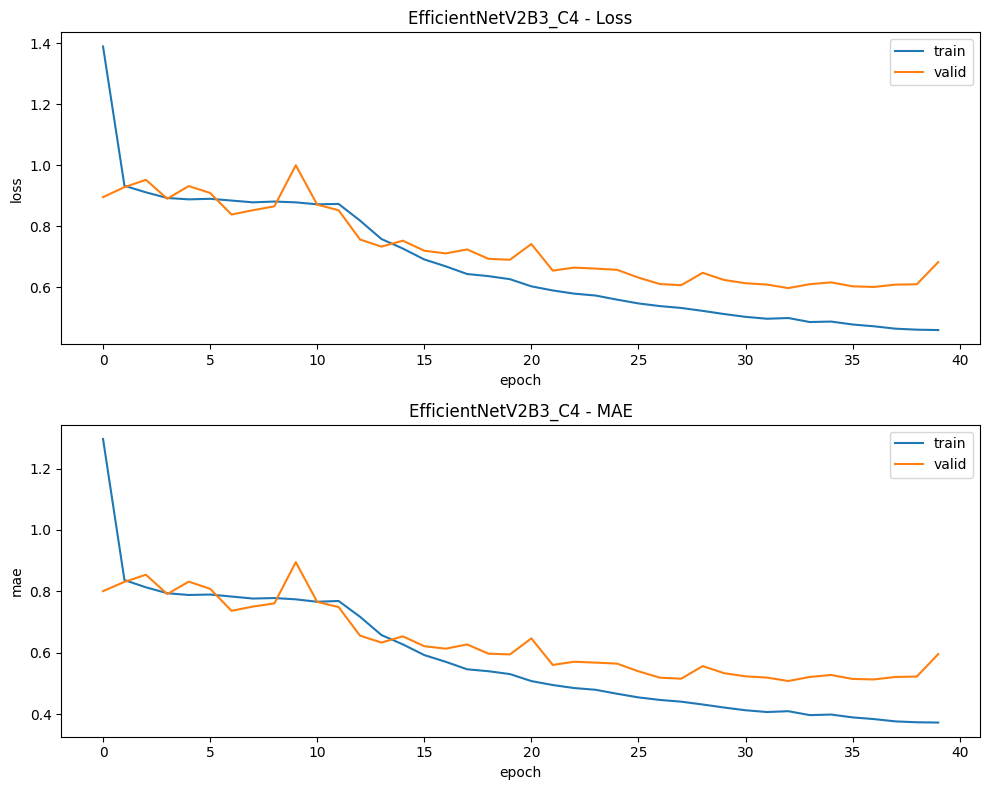

In [6]:
plot_training_history(history, MODEL_NAME)

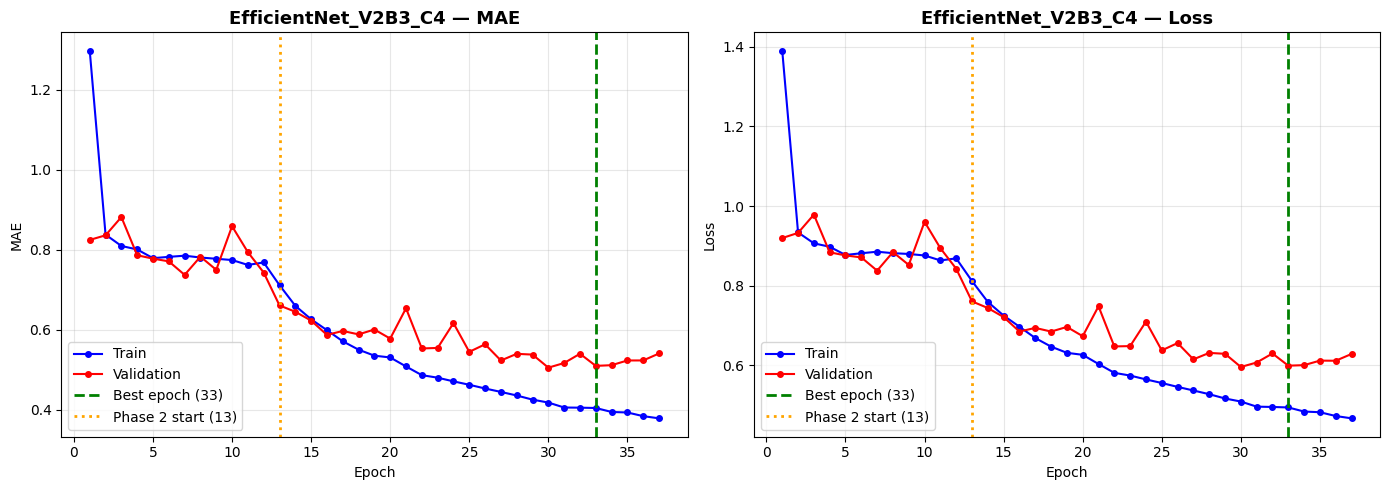

Total epochs: 37 (Phase 1: 12, Phase 2: 25)
Best epoch: 33 (from training notebook logs)
Early stopping at epoch: 37


In [ ]:
# ── Training History Visualization — EfficientNet_V2B3_C4 ───────────────────
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

output_dir = Path.cwd().resolve()
report_dir = output_dir / 'reports'
MODEL_NAME = "EfficientNet_V2B3_C4"

p1 = pd.read_csv(report_dir / 'train_history_phase1.csv')
p2 = pd.read_csv(report_dir / 'train_history_phase2.csv')

p1['epoch'] = p1['epoch'] + 1
p2['epoch'] = p2['epoch'] + 1

history = pd.concat([p1, p2], ignore_index=True)
epoch_labels = history['epoch'].values

best_idx = history['val_accuracy'].idxmax()
best_epoch = int(history.loc[best_idx, 'epoch'])

phase2_start = int(p2['epoch'].iloc[0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# MAE
ax1.plot(epoch_labels, history['mae'], 'b-o', markersize=4, label='Train')
ax1.plot(epoch_labels, history['val_mae'], 'r-o', markersize=4, label='Validation')
ax1.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, label=f'Best epoch ({best_epoch})')
ax1.axvline(x=phase2_start, color='orange', linestyle=':', linewidth=2, label=f'Phase 2 start ({phase2_start})')
ax1.set_title(f'{MODEL_NAME} — MAE', fontsize=13, fontweight='bold')
ax1.set_ylabel('MAE')
ax1.set_xlabel('Epoch')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Loss
ax2.plot(epoch_labels, history['loss'], 'b-o', markersize=4, label='Train')
ax2.plot(epoch_labels, history['val_loss'], 'r-o', markersize=4, label='Validation')
ax2.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, label=f'Best epoch ({best_epoch})')
ax2.axvline(x=phase2_start, color='orange', linestyle=':', linewidth=2, label=f'Phase 2 start ({phase2_start})')
ax2.set_title(f'{MODEL_NAME} — Loss', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Total epochs: {len(history)} (Phase 1: {len(p1)}, Phase 2: {len(p2)})')
print(f'Best epoch: {best_epoch} (from training notebook logs)')
print(f'Early stopping at epoch: {int(epoch_labels[-1])}')


## **7.0 Validation + Test Evaluation**

### **7.1 Validation Result Evaluation**

Loaded best model from: models/best_model.keras
52/52 [==============================] - 5s 58ms/step
Initial thresholds  : [0.5 1.5 2.5 3.5]
Optimized thresholds: [0.5498047 1.3054986 2.5344903 3.8445196]
Saved optimized_thresholds.json

  COMPREHENSIVE EVALUATION METRICS MATRIX
  Model : EfficientNetV2B3_C4
  Split : Validation
  Metric                                        Value
  ------------------------------------------------------------------------
  Overall Accuracy                             0.6489
  Balanced Accuracy                            0.6217
  Mean Absolute Error (MAE)                    0.4431
  Macro ROC AUC (ordinal matrix)               0.8568
  Weighted ROC AUC                             0.8270
  Quadratic Weighted Kappa (QWK)               0.7841

  PER-CLASS BREAKDOWN
  ------------------------------------------------------------------------
  Class           Precision     Recall         F1    Support
  ------------------------------------------------------

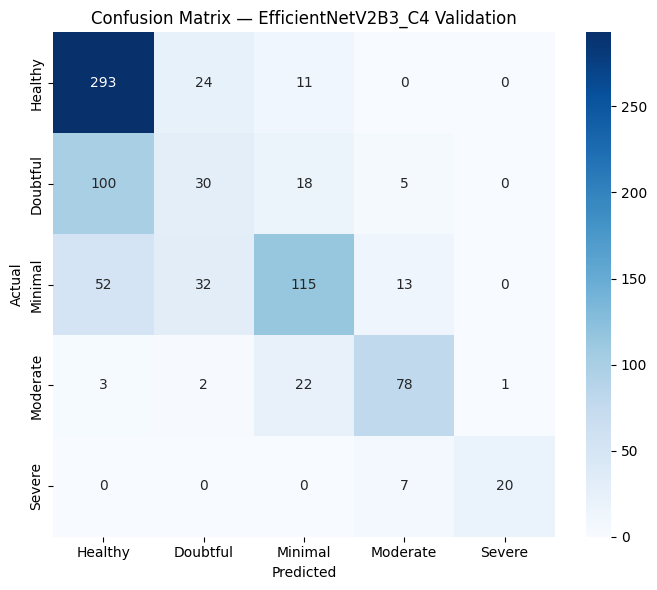

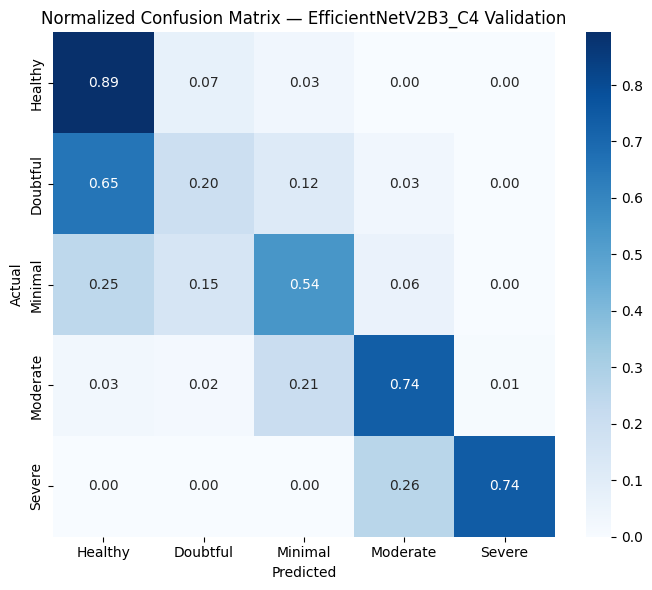

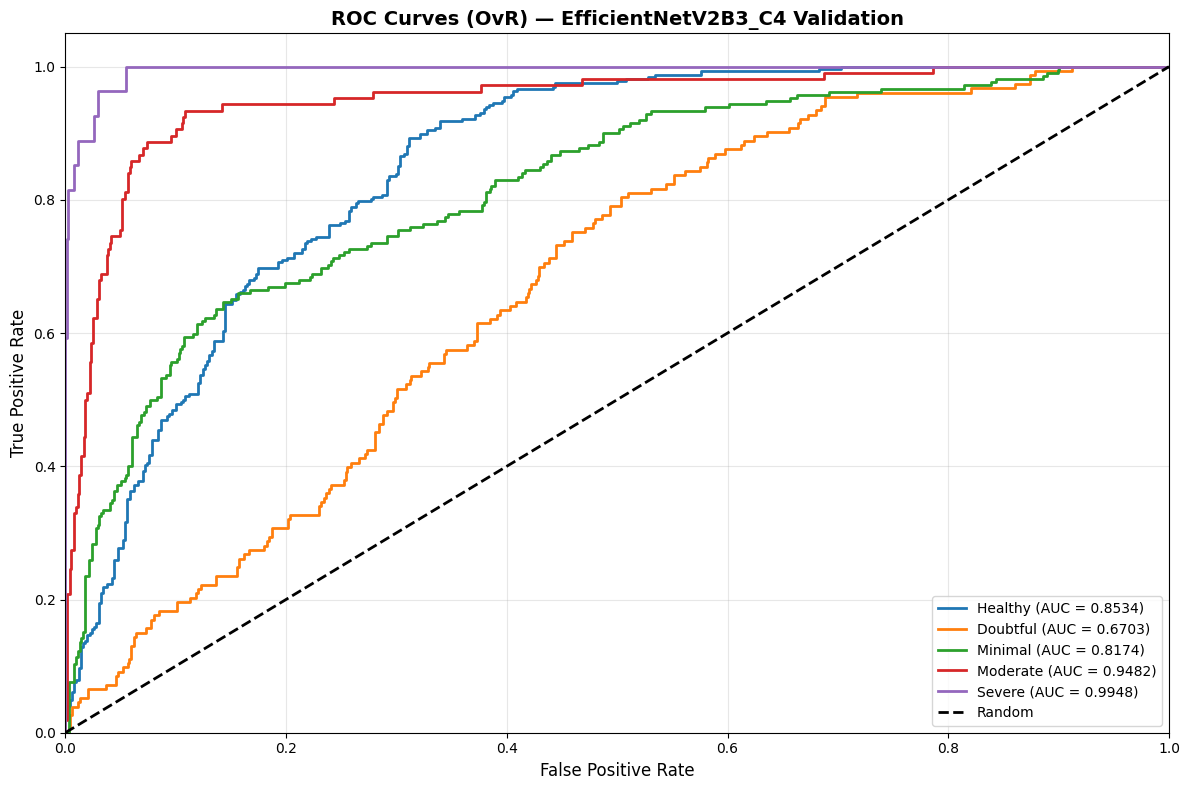

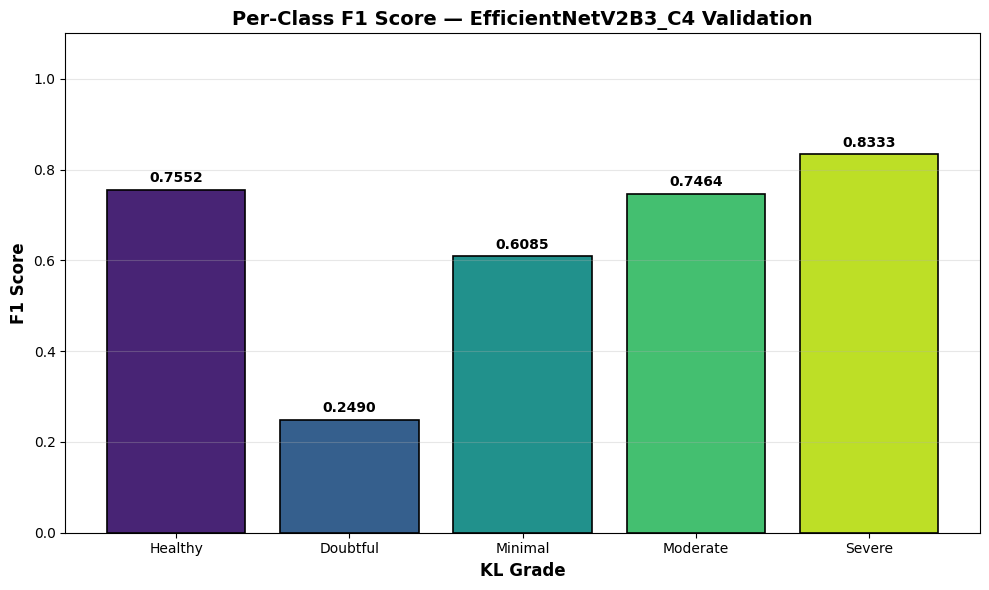

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# VALIDATION — Comprehensive Evaluation Metrics Matrix
# ─────────────────────────────────────────────────────────────────────────────
best_model = tf.keras.models.load_model(best_model_path)
print('Loaded best model from:', best_model_path)

valid_sequence.reset()
val_continuous = best_model.predict(valid_sequence, verbose=1).reshape(-1)
val_true       = valid_sequence.classes


def threshold_objective(thresholds, preds, y_true):
    """Objective function: discrete MAE on thresholded labels (not continuous values)."""
    _, pred_labels = threshold_predictions(preds, thresholds)
    return mean_absolute_error(y_true, pred_labels)  # on integers 0-4


initial_thresholds = np.array([0.5, 1.5, 2.5, 3.5], dtype=np.float32)
threshold_result   = minimize(
    threshold_objective,
    initial_thresholds,
    args=(val_continuous, val_true),
    method='Nelder-Mead',
)
optimized_thresholds = np.sort(threshold_result.x)

_, val_pred_labels = threshold_predictions(val_continuous, optimized_thresholds)

print('Initial thresholds  :', initial_thresholds)
print('Optimized thresholds:', optimized_thresholds)

with open('optimized_thresholds.json', 'w', encoding='utf-8') as f:
    json.dump({'thresholds': optimized_thresholds.tolist()}, f, indent=2)
print('Saved optimized_thresholds.json')

# ── Comprehensive Evaluation Metrics Matrix — Validation ──────────────────────
val_metrics = comprehensive_evaluation_metrics_matrix(
    y_true           = val_true,
    continuous_preds = val_continuous,
    pred_labels      = val_pred_labels,
    split_name       = 'Validation',
    class_names      = CLASS_NAMES,
    model_name       = MODEL_NAME,
)

# ── Confusion matrices ────────────────────────────────────────────────────────
plot_confusion_matrix(val_true, val_pred_labels, CLASS_NAMES,
                      f'Confusion Matrix — {MODEL_NAME} Validation', normalize=False)
plot_confusion_matrix(val_true, val_pred_labels, CLASS_NAMES,
                      f'Normalized Confusion Matrix — {MODEL_NAME} Validation', normalize=True)

# ── ROC curves and per-class F1 ───────────────────────────────────────────────
val_probs = continuous_to_probs(val_continuous)
plot_roc_curves(val_true, val_probs, CLASS_NAMES, f'{MODEL_NAME} Validation')
plot_f1_per_class(val_true, val_pred_labels, CLASS_NAMES, f'{MODEL_NAME} Validation')


### **7.2 Test Results Evaluation**


104/104 [==============================] - 7s 66ms/step

  COMPREHENSIVE EVALUATION METRICS MATRIX
  Model : EfficientNetV2B3_C4
  Split : Test
  Metric                                        Value
  ------------------------------------------------------------------------
  Overall Accuracy                             0.6576
  Balanced Accuracy                            0.5710
  Mean Absolute Error (MAE)                    0.4130
  Macro ROC AUC (ordinal matrix)               0.8845
  Weighted ROC AUC                             0.8660
  Quadratic Weighted Kappa (QWK)               0.8092

  PER-CLASS BREAKDOWN
  ------------------------------------------------------------------------
  Class           Precision     Recall         F1    Support
  ------------------------------------------------------------------------
  Healthy            0.6764     0.9390     0.7864        639
  Doubtful           0.3295     0.1959     0.2458        296
  Minimal            0.7217     0.5280     0.60

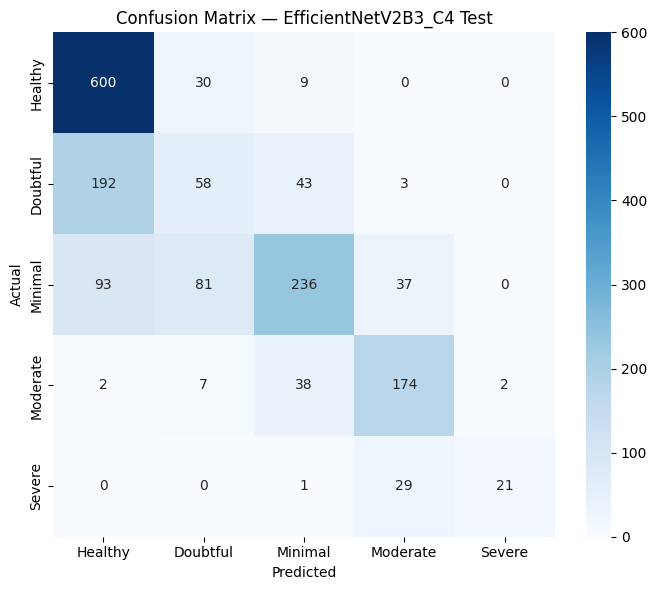

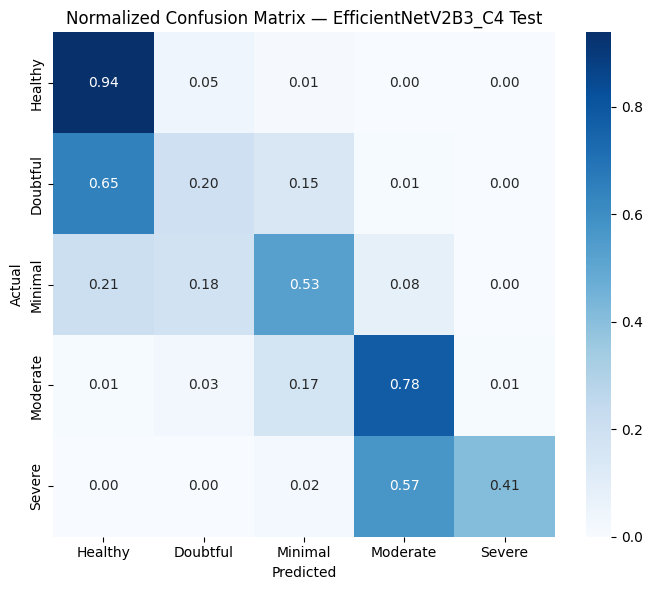

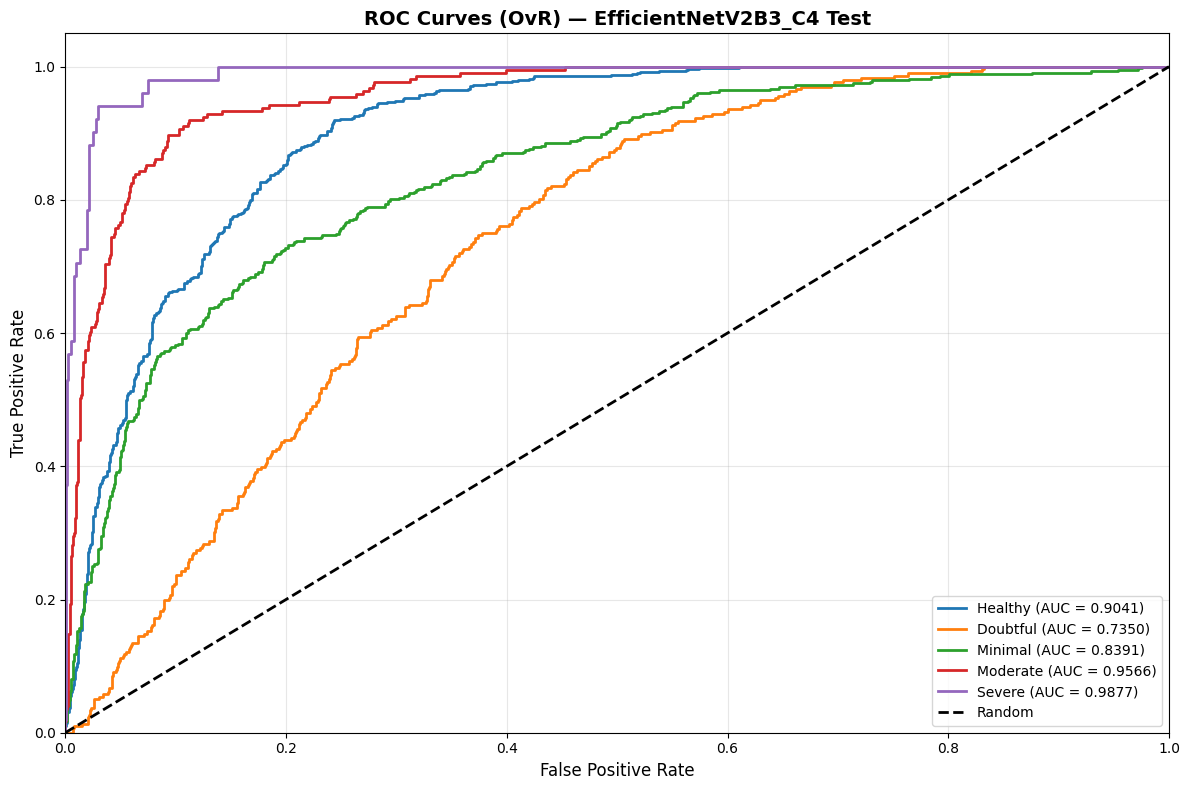

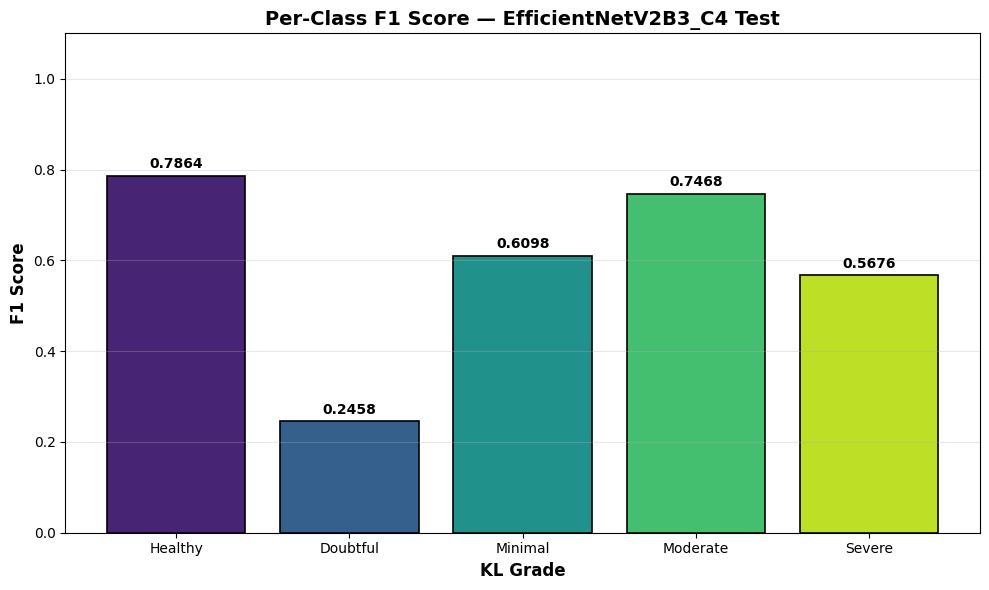


  VALIDATION vs TEST — METRICS COMPARISON
            Overall Accuracy  Balanced Accuracy     MAE  Macro ROC AUC (ordinal)  Weighted ROC AUC  Quadratic Weighted Kappa
Split                                                                                                                       
Validation            0.6489             0.6217  0.4431                   0.8568             0.827                    0.7841
Test                  0.6576             0.5710  0.4130                   0.8845             0.866                    0.8092
Saved metrics_comparison.csv


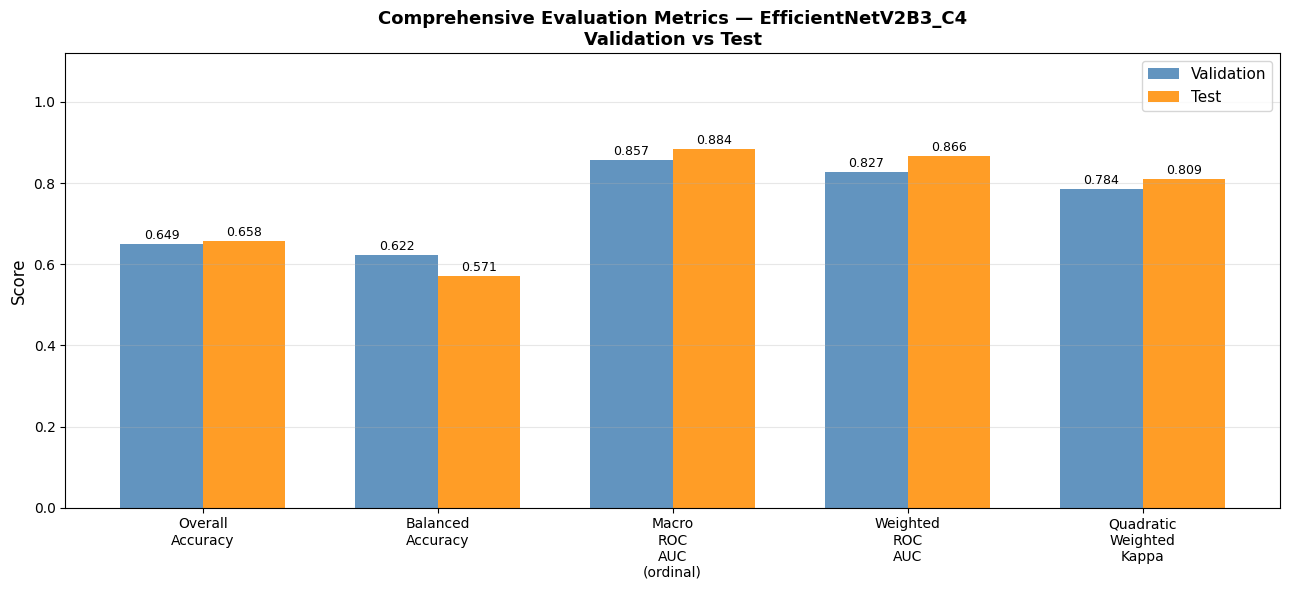

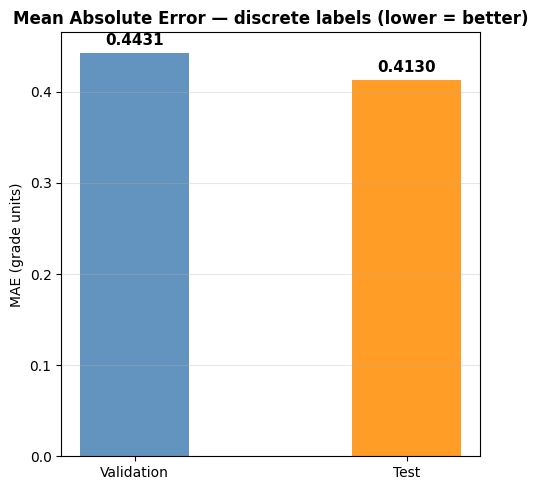

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TEST SET EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

test_sequence.reset()
test_continuous = best_model.predict(test_sequence, verbose=1).reshape(-1)
test_true       = test_sequence.classes
_, test_pred_labels = threshold_predictions(test_continuous, optimized_thresholds)

# ── Comprehensive Evaluation Metrics Matrix — Test ────────────────────────────
test_metrics = comprehensive_evaluation_metrics_matrix(
    y_true           = test_true,
    continuous_preds = test_continuous,
    pred_labels      = test_pred_labels,
    split_name       = 'Test',
    class_names      = CLASS_NAMES,
    model_name       = MODEL_NAME,
)

# ── Full classification report ────────────────────────────────────────────────
test_report = classification_report(test_true, test_pred_labels, target_names=CLASS_NAMES, digits=4)

eval_report = (
    f'Model           : {MODEL_NAME}\n'
    f'Split           : Test\n'
    f'Overall Accuracy: {test_metrics["Overall Accuracy"]:.4f}\n'
    f'Balanced Acc    : {test_metrics["Balanced Accuracy"]:.4f}\n'
    f'MAE             : {test_metrics["MAE"]:.4f}\n'
    f'Macro AUC (ord) : {test_metrics["Macro ROC AUC (ordinal)"]:.4f}\n'
    f'Weighted AUC    : {test_metrics["Weighted ROC AUC"]:.4f}\n'
    f'QWK             : {test_metrics["Quadratic Weighted Kappa"]:.4f}\n\n'
    f'Classification Report:\n{test_report}'
)
with open('eval_report.txt', 'w', encoding='utf-8') as f:
    f.write(eval_report)
print('Saved eval_report.txt')
print(eval_report)

# ── Confusion matrices ────────────────────────────────────────────────────────
plot_confusion_matrix(test_true, test_pred_labels, CLASS_NAMES,
                      f'Confusion Matrix — {MODEL_NAME} Test', normalize=False)
plot_confusion_matrix(test_true, test_pred_labels, CLASS_NAMES,
                      f'Normalized Confusion Matrix — {MODEL_NAME} Test', normalize=True)

# ── ROC curves and per-class F1 ───────────────────────────────────────────────
test_probs = continuous_to_probs(test_continuous)
plot_roc_curves(test_true, test_probs, CLASS_NAMES, f'{MODEL_NAME} Test')
plot_f1_per_class(test_true, test_pred_labels, CLASS_NAMES, f'{MODEL_NAME} Test')

# ── Side-by-side Validation vs Test comparison ────────────────────────────────
print('\n' + '=' * 72)
print('  VALIDATION vs TEST — METRICS COMPARISON')
print('=' * 72)
comparison_df = pd.DataFrame([val_metrics, test_metrics]).set_index('Split')
print(comparison_df.to_string())
print('=' * 72)
comparison_df.to_csv('metrics_comparison.csv')
print('Saved metrics_comparison.csv')

# ── Visual comparison bar chart ───────────────────────────────────────────────
metric_cols = ['Overall Accuracy', 'Balanced Accuracy',
               'Macro ROC AUC (ordinal)', 'Weighted ROC AUC', 'Quadratic Weighted Kappa']
x     = np.arange(len(metric_cols))
width = 0.35
fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, [val_metrics[m]  for m in metric_cols],
               width, label='Validation', color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, [test_metrics[m] for m in metric_cols],
               width, label='Test',       color='darkorange', alpha=0.85)
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([m.replace(' ', '\n') for m in metric_cols], fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Comprehensive Evaluation Metrics — {MODEL_NAME}\nValidation vs Test',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── MAE bar (lower = better, separate scale) ──────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(5, 5))
ax2.bar(['Validation', 'Test'],
        [val_metrics['MAE'], test_metrics['MAE']],
        color=['steelblue', 'darkorange'], alpha=0.85, width=0.4)
for i, v in enumerate([val_metrics['MAE'], test_metrics['MAE']]):
    ax2.text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom',
             fontsize=11, fontweight='bold')
ax2.set_title('Mean Absolute Error — discrete labels (lower = better)',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('MAE (grade units)')
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## **8.0 Model Interpretability & Visualization**

### GradCAM Functions
These functions generate heatmaps showing which regions of each X-ray the model focuses on when making predictions. This helps validate that the model is identifying clinically relevant features associated with osteoarthritis.

Test data - Healthy


/tmp/ipykernel_20758/3293148728.py:183: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap('jet')


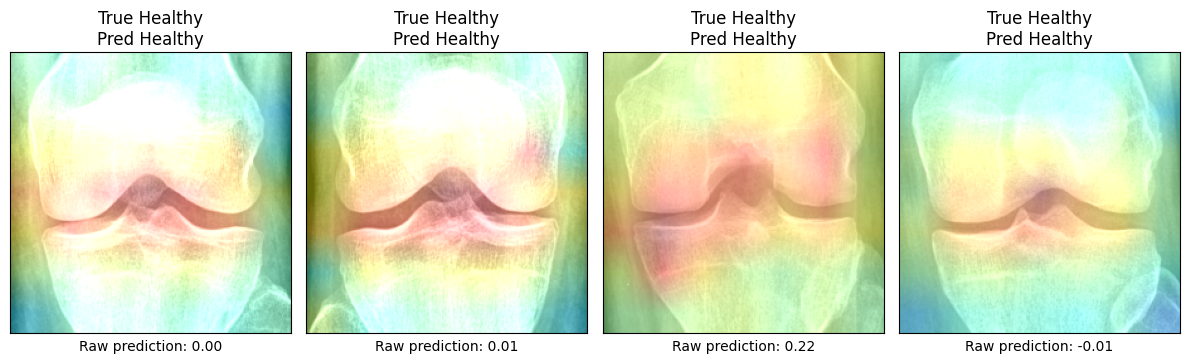

Test data - Doubtful


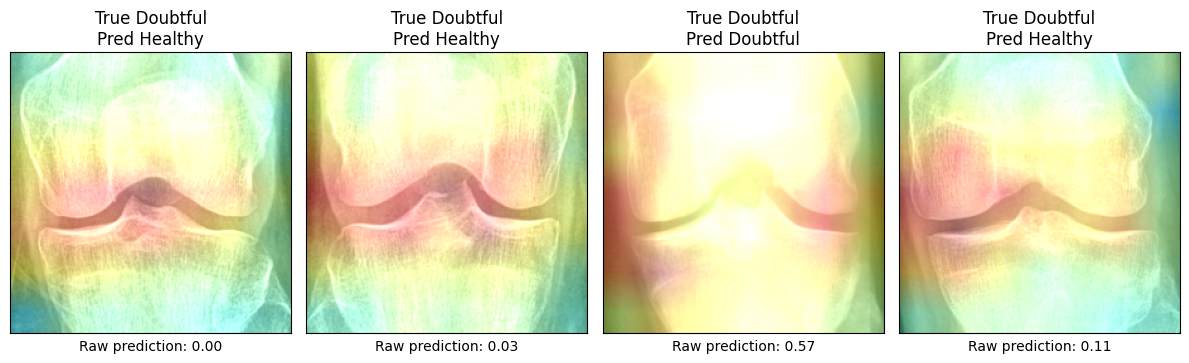

Test data - Minimal


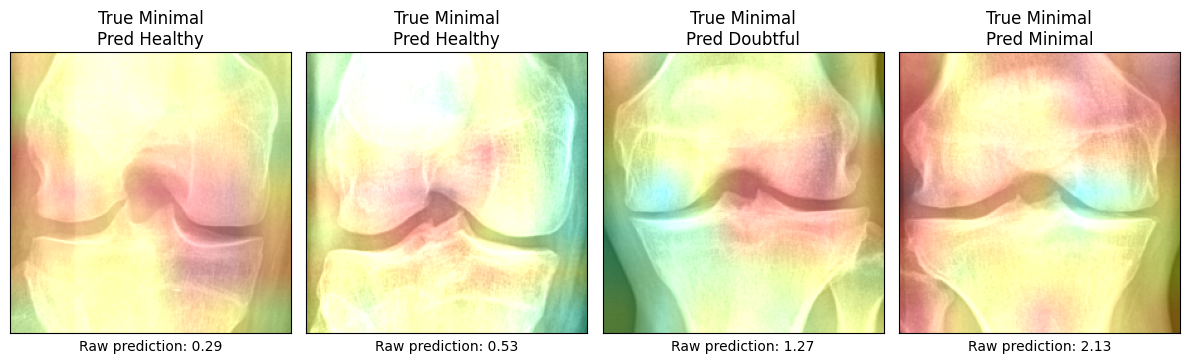

Test data - Moderate


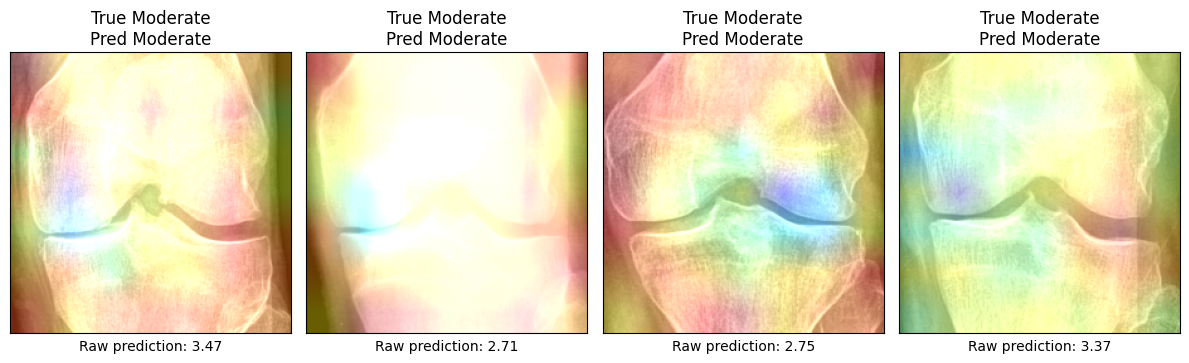

Test data - Severe


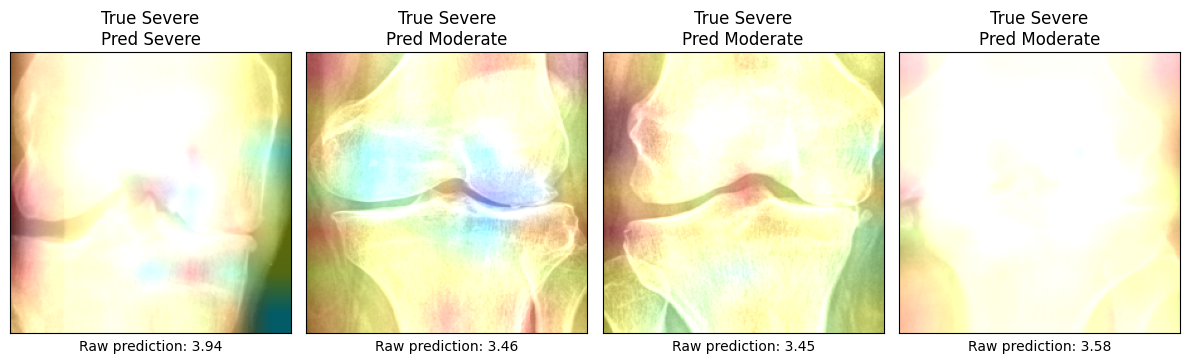

In [9]:
backbone = next(
    layer for layer in best_model.layers
    if isinstance(layer, tf.keras.Model) and 'efficientnetv2' in layer.name.lower()
 )
last_conv_layer_name = get_last_conv_layer_name(backbone)

feature_model = tf.keras.models.Model(
    inputs=backbone.input,
    outputs=backbone.get_layer(last_conv_layer_name).output,
)

# The head must start from GlobalAveragePooling2D (index 2) which collapses
# the 4-D conv output to a 1-D vector before the Dense layers.
# The feature_model already stops at the last conv layer, so we feed its
# 4-D spatial output (shape [B, H, W, C]) into a head that begins with GAP.
gradcam_input = layers.Input(shape=feature_model.output_shape[1:])  # (H, W, C)
x = gradcam_input
for layer in best_model.layers[2:]:  # starts at GlobalAveragePooling2D
    if isinstance(layer, layers.Dropout) or isinstance(layer, layers.BatchNormalization):
        x = layer(x, training=False)
    else:
        x = layer(x)
gradcam_head_model = models.Model(gradcam_input, x, name='gradcam_head')

def make_gradcam_heatmap(feature_model, head_model, img_array):
    with tf.GradientTape() as tape:
        last_conv_layer_output = feature_model(img_array)
        tape.watch(last_conv_layer_output)
        preds = head_model(last_conv_layer_output)
        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output * pooled_grads
    heatmap = tf.reduce_sum(heatmap, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())
    return heatmap.numpy()

for class_index, image_names in test_data.items():
    print(f'Test data - {CLASS_NAMES[class_index]}')
    plt.figure(figsize=(12, 5))
    for image_index, image_name in enumerate(image_names[:4]):
        image_path = os.path.join(str(TEST_PATH), str(class_index), image_name)
        raw_image = Image.open(image_path).convert('RGB')
        display_image = prepare_display_image(raw_image)
        img_array = preprocess_for_efficientnet_c3(raw_image)
        img_array = np.expand_dims(img_array, axis=0)

        y_pred = float(best_model.predict(img_array, verbose=0)[0][0])
        heatmap = make_gradcam_heatmap(feature_model, gradcam_head_model, img_array)
        superimposed_image = overlay_heatmap(display_image, heatmap)
        predicted_label = threshold_predictions(np.array([y_pred]), optimized_thresholds)[1][0]

        plt.subplot(1, 4, image_index + 1, xticks=[], yticks=[])
        plt.imshow(superimposed_image)
        plt.title(f'True {CLASS_NAMES[class_index]}\nPred {CLASS_NAMES[predicted_label]}')
        plt.xlabel(f'Raw prediction: {y_pred:.2f}')
    plt.tight_layout()
    plt.show()
